# GDL Active Learning Dashboard
Add your latest test results to `data/raw/`, then run all cells.
All paths are relative to the project root (`pemfc-gp/`).

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({
    "figure.dpi": 120, "font.size": 11, "axes.titlesize": 13,
    "axes.labelsize": 11, "legend.fontsize": 9, "figure.facecolor": "white",
})

# --- Locate project root ---------------------------------------------------
def _find_project_root():
    start_dirs = []
    nb = globals().get("__vsc_ipynb_file__")
    if nb:
        start_dirs.append(os.path.dirname(os.path.realpath(nb)))
    start_dirs.append(os.getcwd())
    for start in start_dirs:
        d = os.path.abspath(start)
        for _ in range(10):
            if os.path.isdir(os.path.join(d, "src")) and os.path.isdir(os.path.join(d, "data")):
                return d
            d = os.path.dirname(d)
    raise RuntimeError("Cannot find pemfc-gp project root (expected src/ and data/)")

PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print(f"Project root: {PROJECT_ROOT}")

from src.data_parser import load_and_sanitize_data
from src.gp_model import FuelCellSurrogate
from src.optimizer import get_next_experiment, get_batch_experiments

try:
    X_train, y_train = load_and_sanitize_data("data/raw/", "data/processed/")
    print(f"Loaded {len(y_train)} observations.  Arrays saved to data/processed/")
except Exception as e:
    print(f"DATA ERROR: {e}")

Project root: /Users/qiutianyi/Library/CloudStorage/GoogleDrive-qiutianyi3@gmail.com/My Drive/Acedia_SPEIT/Githubrepos/pemfc-physics-gp
Loaded 12 observations.  Arrays saved to data/processed/


GP fitted.
Optimised kernel: 1.58**2 * Matern(length_scale=[1.02, 3.31], nu=2.5) + WhiteKernel(noise_level=0.00314)
Log-marginal likelihood: -9.641



/Users/qiutianyi/miniforge3/envs/pemfcgp/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/qiutianyi/miniforge3/envs/pemfcgp/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/qiutianyi/miniforge3/envs/pemfcgp/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/qiu

LOO RMSE: 0.0330 V  (6.4% of mean)



/Users/qiutianyi/miniforge3/envs/pemfcgp/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


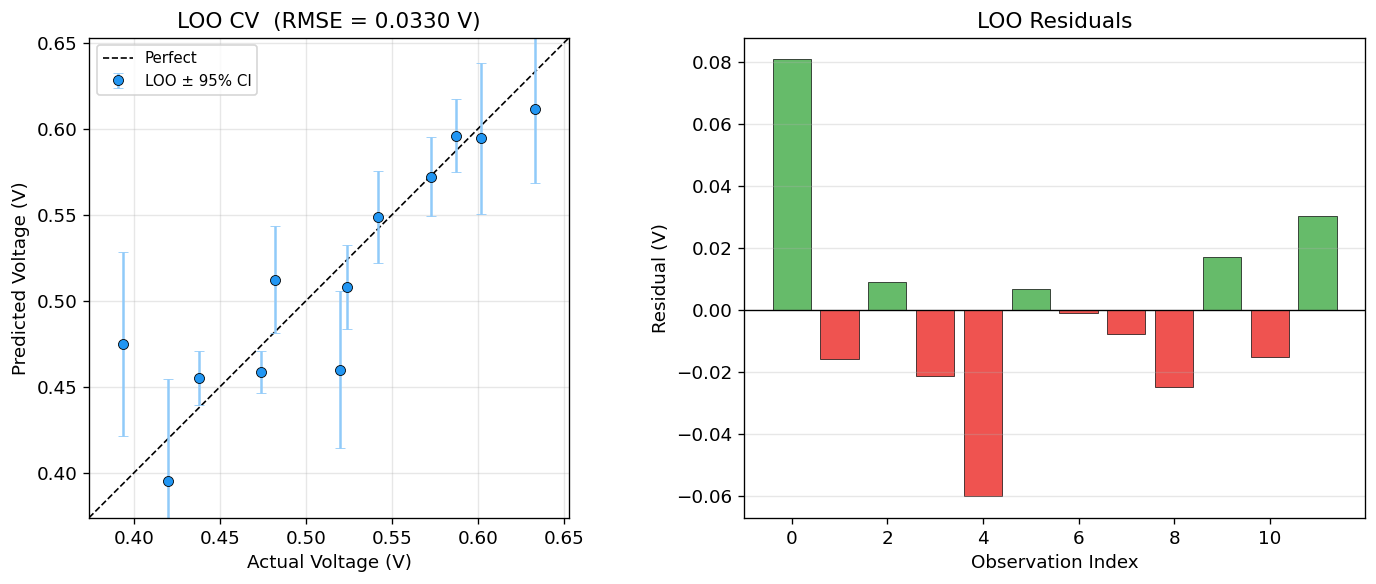

In [2]:
# --- Train GP & LOO cross-validation ---------------------------------------
model = FuelCellSurrogate()
model.fit(X_train, y_train)
print("GP fitted.")

# Verify ARD length scales — both should be finite and comparable
print(f"Optimised kernel: {model.gp.kernel_}")
print(f"Log-marginal likelihood: {model.gp.log_marginal_likelihood_value_:.3f}\n")

y_true, y_pred_loo, y_std_loo, rmse = model.loo_cross_validate(X_train, y_train)
print(f"LOO RMSE: {rmse:.4f} V  ({rmse / y_train.mean() * 100:.1f}% of mean)\n")

# --- LOO diagnostic plots --------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs actual
vmin = min(y_true.min(), y_pred_loo.min()) - 0.02
vmax = max(y_true.max(), y_pred_loo.max()) + 0.02
ax1.plot([vmin, vmax], [vmin, vmax], "k--", lw=1, label="Perfect")
ax1.errorbar(y_true, y_pred_loo, yerr=1.96 * y_std_loo, fmt="o",
             color="#2196F3", ecolor="#90CAF9", elinewidth=1.5, capsize=3,
             ms=6, mec="black", mew=0.5, label="LOO ± 95% CI")
ax1.set(xlabel="Actual Voltage (V)", ylabel="Predicted Voltage (V)",
        title=f"LOO CV  (RMSE = {rmse:.4f} V)", xlim=(vmin, vmax), ylim=(vmin, vmax))
ax1.set_aspect("equal")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# Residuals
residuals = y_pred_loo - y_true
colors = ["#EF5350" if r < 0 else "#66BB6A" for r in residuals]
ax2.bar(range(len(residuals)), residuals, color=colors, edgecolor="black", lw=0.4)
ax2.axhline(0, color="black", lw=0.8)
ax2.set(xlabel="Observation Index", ylabel="Residual (V)", title="LOO Residuals")
ax2.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# --- Suggest next experiments -----------------------------------------------
bounds = [(0, 0.1), (20, 100)]

next_point, X_grid, ei = get_next_experiment(model, X_train, y_train, bounds)
print("TOP RECOMMENDATION")
print(f"  TiO₂ Loading : {next_point[0]:.4f} mg/cm²")
print(f"  RH           : {next_point[1]:.1f} %\n")

batch, _, _ = get_batch_experiments(
    model, X_train, y_train, bounds, k=5, min_distance=0.15,
)
print("BATCH SUGGESTIONS (diverse, ranked by EI):")
for i, pt in enumerate(batch, 1):
    print(f"  {i}.  Loading = {pt[0]:.4f} mg/cm²,  RH = {pt[1]:.1f} %")

TOP RECOMMENDATION
  TiO₂ Loading : 0.0212 mg/cm²
  RH           : 100.0 %

BATCH SUGGESTIONS (diverse, ranked by EI):
  1.  Loading = 0.0212 mg/cm²,  RH = 100.0 %
  2.  Loading = 0.0222 mg/cm²,  RH = 87.9 %
  3.  Loading = 0.0364 mg/cm²,  RH = 100.0 %
  4.  Loading = 0.0061 mg/cm²,  RH = 100.0 %
  5.  Loading = 0.0273 mg/cm²,  RH = 76.6 %


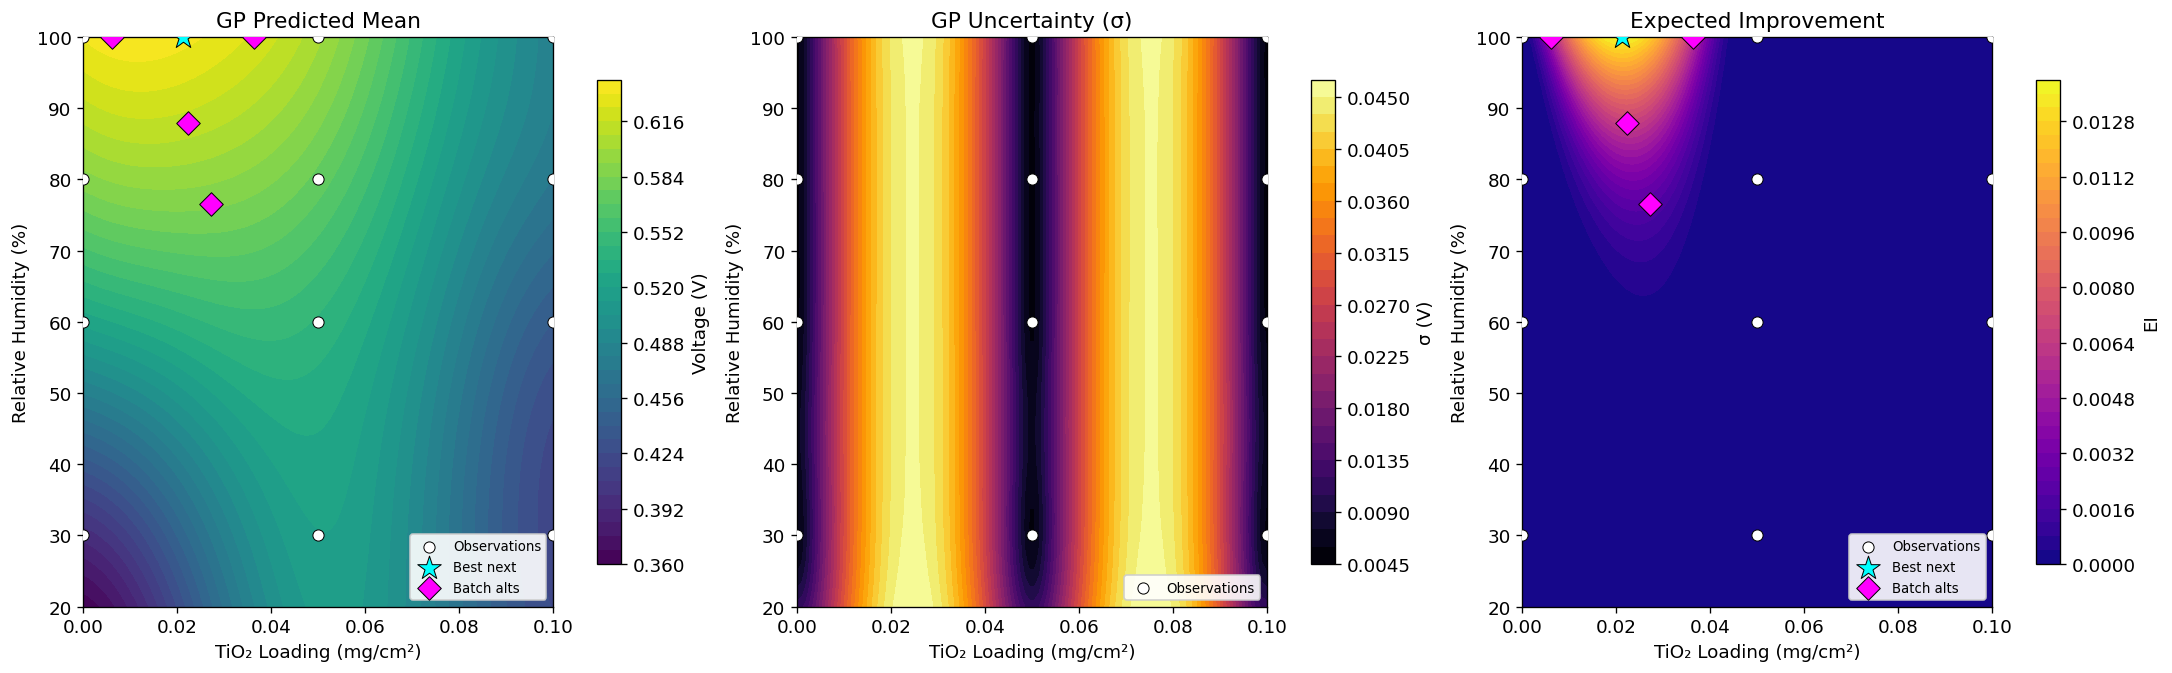

In [4]:
# --- 3-panel visualisation: Mean · Uncertainty · EI ------------------------
res = 100
L_plot = np.linspace(*bounds[0], res)
R_plot = np.linspace(*bounds[1], res)
L_mesh, R_mesh = np.meshgrid(L_plot, R_plot)
X_plot = np.c_[L_mesh.ravel(), R_mesh.ravel()]

mu_plot, std_plot = model.predict(X_plot, return_std=True)
mu_mesh  = mu_plot.reshape(res, res)
std_mesh = std_plot.reshape(res, res)
ei_mesh  = ei.reshape(res, res)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)
sc_kw = dict(edgecolors="black", linewidths=0.6, zorder=5)

# Panel 1 — GP mean
ax = axes[0]
cf = ax.contourf(L_mesh, R_mesh, mu_mesh, levels=40, cmap="viridis")
fig.colorbar(cf, ax=ax, label="Voltage (V)", shrink=0.85)
ax.scatter(X_train[:, 0], X_train[:, 1], c="white", s=45, marker="o",
           label="Observations", **sc_kw)
ax.scatter(*next_point, c="cyan", s=220, marker="*", label="Best next", **sc_kw)
if len(batch) > 1:
    ax.scatter(batch[1:, 0], batch[1:, 1], c="magenta", s=100, marker="D",
               label="Batch alts", **sc_kw)
ax.set(title="GP Predicted Mean", xlabel="TiO₂ Loading (mg/cm²)",
       ylabel="Relative Humidity (%)")
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)

# Panel 2 — Uncertainty (σ)
ax = axes[1]
cf2 = ax.contourf(L_mesh, R_mesh, std_mesh, levels=40, cmap="inferno")
fig.colorbar(cf2, ax=ax, label="σ (V)", shrink=0.85)
ax.scatter(X_train[:, 0], X_train[:, 1], c="white", s=45, marker="o",
           label="Observations", **sc_kw)
ax.set(title="GP Uncertainty (σ)", xlabel="TiO₂ Loading (mg/cm²)",
       ylabel="Relative Humidity (%)")
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)

# Panel 3 — Expected Improvement
ax = axes[2]
cf3 = ax.contourf(L_mesh, R_mesh, ei_mesh, levels=40, cmap="plasma")
fig.colorbar(cf3, ax=ax, label="EI", shrink=0.85)
ax.scatter(X_train[:, 0], X_train[:, 1], c="white", s=45, marker="o",
           label="Observations", **sc_kw)
ax.scatter(*next_point, c="cyan", s=220, marker="*", label="Best next", **sc_kw)
if len(batch) > 1:
    ax.scatter(batch[1:, 0], batch[1:, 1], c="magenta", s=100, marker="D",
               label="Batch alts", **sc_kw)
ax.set(title="Expected Improvement", xlabel="TiO₂ Loading (mg/cm²)",
       ylabel="Relative Humidity (%)")
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)

plt.show()